# Premier League 2025-26: Predicted vs Actual Goals + Assists

**Aim:** predict each outfield player's goals + assists (`goalsAssistsSum`) from their shooting and chance-creation stats, compare with what actually happened, and choose the best model.

**Day 1 (this notebook so far):** load and clean the data, remove leakage columns, look at the data, compute the xG + xA benchmark, and fit a first Ridge model.

## 1. Setup

In [1]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from sklearn.compose import ColumnTransformer
from sklearn.linear_model import Ridge
from sklearn.metrics import mean_absolute_error, r2_score
from sklearn.model_selection import KFold, cross_validate, train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler

RANDOM_STATE = 42
DATA_PATH = Path("../data/premier_league_complete_stats_whole2025-2026_season.csv")
OUTPUT_DIR = Path("../outputs")

## 2. Load the data

Check the real column names first so no feature name is made up.

In [2]:
df = pd.read_csv(DATA_PATH)
print(df.shape)
print(df["team_name"].value_counts())

(78, 113)
team_name
Manchester United    27
Manchester City      26
Arsenal              25
Name: count, dtype: int64


In [3]:
list(df.columns)

['player_name',
 'player_id',
 'team_name',
 'team_id',
 'position',
 'accurateChippedPasses',
 'accurateCrosses',
 'accurateCrossesPercentage',
 'accurateFinalThirdPasses',
 'accurateLongBalls',
 'accurateLongBallsPercentage',
 'accurateOppositionHalfPasses',
 'accurateOwnHalfPasses',
 'accuratePasses',
 'accuratePassesPercentage',
 'aerialDuelsWon',
 'aerialDuelsWonPercentage',
 'aerialLost',
 'appearances',
 'assists',
 'attemptPenaltyMiss',
 'attemptPenaltyPost',
 'ballRecovery',
 'bigChancesCreated',
 'bigChancesMissed',
 'blockedShots',
 'cleanSheet',
 'clearances',
 'countRating',
 'directRedCards',
 'dispossessed',
 'dribbledPast',
 'duelLost',
 'errorLeadToGoal',
 'errorLeadToShot',
 'expectedAssists',
 'expectedGoals',
 'fouls',
 'freeKickGoal',
 'goalConversionPercentage',
 'goalKicks',
 'goals',
 'goalsAssistsSum',
 'goalsConceded',
 'goalsConcededInsideTheBox',
 'goalsConcededOutsideTheBox',
 'goalsFromInsideTheBox',
 'goalsFromOutsideTheBox',
 'goalsPrevented',
 'groundDu

## 3. Cleaning

Three filters, in order:
1. **Drop rows with no stats.** 16 squad players have no stats at all (they never played), so there is nothing to learn from.
2. **Outfield only.** Goalkeepers almost never score or assist, and their stats measure a different job.
3. **At least 5 appearances.** A player with 1–2 games has G+A that's mostly noise.

In [4]:
print("Rows with no appearances recorded:", df["appearances"].isna().sum())

players = df[df["appearances"].notna()]
players = players[~players["position"].str.startswith("G")]
players = players[players["appearances"] >= 5].copy()

print("Players after cleaning:", len(players))
print(players["position"].value_counts())

Rows with no appearances recorded: 16
Players after cleaning: 55
position
D    23
M    22
F    10
Name: count, dtype: int64


## 4. Leakage check

A column **leaks** if it contains the answer, or is calculated from it. For example, `goals` is part of `goalsAssistsSum`, so a model given `goals` would look amazing and learn nothing useful.

The list below is the one from the project instructions, plus extras found in this CSV:
- **Penalty and foot-specific goals:** `penaltyGoals`, `penaltyConversion`, `leftFootGoals`, `rightFootGoals`.
- **Rates with goals in them:** `scoringFrequency` (minutes per goal), `setPieceConversion`.
- **Ratings:** `rating`, `totalRating`, `countRating`, `totwAppearances`. Rating systems reward goals and assists, so they indirectly contain the target.
- **`passToAssist`:** not identical to assists here (it matches in only 29% of rows), but it's unclear how it's defined, so it's safer left out.

In [5]:
TARGET = "goalsAssistsSum"

LEAKAGE_COLS = [
    "goals", "assists", "goalsAssistsSum", "goalConversionPercentage",
    "goalsFromInsideTheBox", "goalsFromOutsideTheBox", "headedGoals", "freeKickGoal",
    "penaltyGoals", "penaltyConversion", "leftFootGoals", "rightFootGoals",
    "scoringFrequency", "setPieceConversion", "passToAssist",
    "rating", "totalRating", "countRating", "totwAppearances",
]

# Provider's own estimate: used as the benchmark, never as a feature
BENCHMARK_COLS = ["expectedGoals", "expectedAssists"]

## 5. Features

These come from the candidate list in the instructions, checked against the real column names above.

`totalAttemptAssist` is also in the CSV, but it's identical to `keyPasses` (correlation 1.00), so only `keyPasses` is used. Giving the model the same column twice adds nothing and makes Ridge's coefficients harder to read.

In [6]:
print(players[["keyPasses", "totalAttemptAssist"]].corr().round(3))

                    keyPasses  totalAttemptAssist
keyPasses                 1.0                 1.0
totalAttemptAssist        1.0                 1.0


In [7]:
NUMERIC_FEATURES = [
    # Shooting and chance creation
    "totalShots", "shotsOnTarget", "blockedShots",
    "bigChancesCreated", "bigChancesMissed", "keyPasses",
    "attemptPenaltyMiss", "attemptPenaltyPost",
    # Involvement
    "appearances", "minutesPlayed",
    "accurateFinalThirdPasses", "accurateOppositionHalfPasses",
    "accurateCrosses", "dispossessed",
]
CATEGORICAL_FEATURES = ["position"]
FEATURES = NUMERIC_FEATURES + CATEGORICAL_FEATURES

leaked = set(FEATURES) & set(LEAKAGE_COLS + BENCHMARK_COLS)
assert not leaked, f"Leakage columns in features: {leaked}"
print("No leakage columns in the feature list.")

No leakage columns in the feature list.


**Missing values:** after cleaning, check what's still missing. A missing count means the event never happened, so it's filled with 0.

In [8]:
print("Missing in features:", players[NUMERIC_FEATURES].isna().sum().sum())
print("Missing in benchmark:")
print(players.loc[players[BENCHMARK_COLS].isna().any(axis=1), ["player_name", *BENCHMARK_COLS]])

players[NUMERIC_FEATURES] = players[NUMERIC_FEATURES].fillna(0)
players[BENCHMARK_COLS] = players[BENCHMARK_COLS].fillna(0)

Missing in features: 0
Missing in benchmark:
    player_name  expectedGoals  expectedAssists
49  John Stones            NaN         0.087636


## 6. Exploring the data

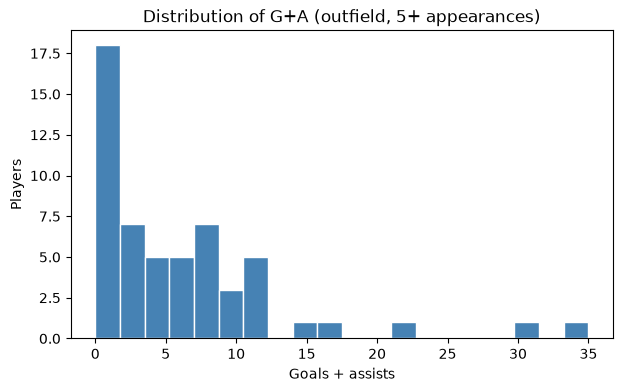

count    55.000000
mean      6.109091
std       7.051852
min       0.000000
25%       1.000000
50%       5.000000
75%       8.000000
max      35.000000
Name: goalsAssistsSum, dtype: float64

In [9]:
fig, ax = plt.subplots(figsize=(7, 4))
ax.hist(players[TARGET], bins=20, color="steelblue", edgecolor="white")
ax.set_xlabel("Goals + assists")
ax.set_ylabel("Players")
ax.set_title("Distribution of G+A (outfield, 5+ appearances)")
plt.show()

players[TARGET].describe()

The target is **right-skewed**: most players have a handful of G+A and a few attackers have far more. The high-G+A players will dominate squared-error losses, which is one reason MAE is also reported.

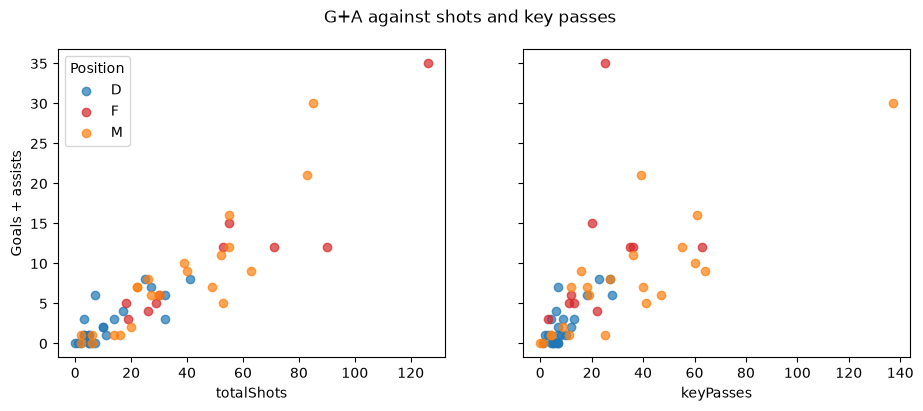

In [10]:
colors = {"D": "tab:blue", "M": "tab:orange", "F": "tab:red"}
fig, axes = plt.subplots(1, 2, figsize=(11, 4), sharey=True)
for ax, col in zip(axes, ["totalShots", "keyPasses"]):
    for pos, grp in players.groupby("position"):
        ax.scatter(grp[col], grp[TARGET], label=pos, color=colors[pos], alpha=0.7)
    ax.set_xlabel(col)
axes[0].set_ylabel("Goals + assists")
axes[0].legend(title="Position")
fig.suptitle("G+A against shots and key passes")
plt.show()

In [11]:
players.groupby("position")[TARGET].agg(["count", "mean", "median", "max"]).round(1)

,count,mean,median,max
position,,,,
D,23,2.5,1.0,8.0
F,10,10.9,9.0,35.0
M,22,7.7,7.0,30.0


## 7. Train/test split

80/20 split with `random_state=42`. The same split is used for the benchmark and the models so they're compared on the same players.

With 55 players, the test set is only 11 players, so one unlucky split can move the scores a lot. Compare the two sets:

In [12]:
X = players[FEATURES]
y = players[TARGET]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=RANDOM_STATE
)
print(f"Train: {len(X_train)} players, test: {len(X_test)} players")
pd.DataFrame({"train": y_train.describe(), "test": y_test.describe()}).round(2)

Train: 44 players, test: 11 players


,train,test
count,44.00,11.00
mean,6.80,3.36
std,7.67,2.25
min,0.00,1.00
25%,1.00,1.00
50%,6.00,4.00
75%,9.25,5.00
max,35.00,7.00


The test set has a much smaller spread of G+A (std ≈ 2.3 vs ≈ 7.7) and none of the high scorers. R² measures how much of the target's *variance* a model explains, and there's very little variance in this test set, so **test R² will look bad for any model**. MAE (average error in G+A) is more trustworthy here, and section 10 adds cross-validation for a fairer picture.

## 8. Benchmark: xG + xA

`expectedGoals + expectedAssists` is the data provider's estimate of how many G+A a player *should* have. It's built from shot-level data (shot location, angle, type of pass) that isn't in this CSV, so it's a strong target to match.

In [13]:
players["xg_xa"] = players["expectedGoals"] + players["expectedAssists"]

def scores(y_true, y_pred):
    return {"R2": r2_score(y_true, y_pred), "MAE": mean_absolute_error(y_true, y_pred)}

bench_all = scores(y, players["xg_xa"])
bench_test = scores(y_test, players.loc[X_test.index, "xg_xa"])
pd.DataFrame({"all 55 players": bench_all, "test set (11)": bench_test}).round(3)

,all 55 players,test set (11)
R2,0.894,0.201
MAE,1.580,1.253


On all 55 players xG + xA explains most of the variance (R² ≈ 0.89). On the small test set its R² drops sharply, but its MAE stays around 1.3 G+A. That confirms the test-set R² problem above is about the split, not the predictor.

## 9. First model: Ridge regression

Why this setup:
- **`Pipeline` + `ColumnTransformer`:** the scaler and encoder are fitted inside the pipeline on training data only, so test-set statistics can't leak into training.
- **`StandardScaler`:** Ridge penalises large coefficients, so features need to be on the same scale for the penalty to be fair.
- **`OneHotEncoder(handle_unknown="ignore")`:** turns `position` into 0/1 columns and won't crash if a split is missing a position.
- **Ridge rather than plain linear regression:** shots, shots on target and big chances missed are strongly correlated. Ridge's penalty keeps the coefficients stable when features overlap like that.
- **Clip at 0:** negative goals + assists is impossible.

In [14]:
preprocess = ColumnTransformer([
    ("num", StandardScaler(), NUMERIC_FEATURES),
    ("cat", OneHotEncoder(handle_unknown="ignore"), CATEGORICAL_FEATURES),
])

ridge = Pipeline([
    ("preprocess", preprocess),
    ("model", Ridge(alpha=1.0)),
])

ridge.fit(X_train, y_train)
ridge_pred = np.clip(ridge.predict(X_test), 0, None)

pd.DataFrame({
    "xG + xA (benchmark)": bench_test,
    "Ridge": scores(y_test, ridge_pred),
}).T.round(3)

,R2,MAE
xG + xA (benchmark),0.201,1.253
Ridge,-0.885,2.081


In [15]:
test_view = pd.DataFrame({
    "player": players.loc[X_test.index, "player_name"],
    "position": X_test["position"],
    "actual": y_test,
    "ridge": ridge_pred.round(1),
    "xG + xA": players.loc[X_test.index, "xg_xa"].round(1),
}).sort_values("actual", ascending=False)
test_view

,player,position,actual,ridge,xG + xA
6,Martin Ødegaard,M,7.0,6.0,4.9
28,Marc Guéhi,D,6.0,8.7,6.4
21,Gabriel Martinelli,F,5.0,8.0,5.3
59,Amad Diallo,M,5.0,12.8,10.4
36,Joško Gvardiol,D,4.0,2.7,3.1
14,Noni Madueke,F,4.0,5.8,4.1
46,Savinho,M,2.0,5.3,3.9
37,Nico González,M,1.0,1.6,1.8
15,Ben White,D,1.0,1.3,1.1
56,Matthijs de Ligt,D,1.0,1.7,2.2


## 10. Stability check: 5-fold cross-validation

To see whether the test-set result is down to the model or the split, the same pipeline is trained and scored 5 times. Each time a different fifth of the players is held out, and every player is tested exactly once. `shuffle=True` because the CSV is sorted by team.

In [16]:
cv = KFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)
cv_results = cross_validate(ridge, X, y, cv=cv, scoring=["r2", "neg_mean_absolute_error"])

cv_table = pd.DataFrame({
    "R2": cv_results["test_r2"],
    "MAE": -cv_results["test_neg_mean_absolute_error"],
}, index=[f"fold {i + 1}" for i in range(5)])
cv_table.loc["mean"] = cv_table.mean()
cv_table.loc["std"] = cv_table.iloc[:5].std()
cv_table.round(3)

,R2,MAE
fold 1,-0.885,2.081
fold 2,0.805,2.444
fold 3,0.881,1.953
fold 4,0.788,2.044
fold 5,0.926,1.104
mean,0.503,1.925
std,0.778,0.496


### Day 1 takeaways

- One fold (the one with the low-spread test players) gives a negative R²; the others give roughly 0.8–0.9. **One 80/20 split isn't enough to judge a model on 55 players.** Day 2 compares models on cross-validated MAE, as set out in `PLAN.md`.
- Ridge's MAE is about 2 G+A per player, worse than the xG + xA benchmark on the test set. That's expected: xG + xA uses shot-quality data we don't have.
- **Day 2:** add Random Forest and Gradient Boosting, compare all models on 5-fold CV MAE, choose the best, and plot predicted vs actual for all 55 players.

*Note: `cross_validate` doesn't clip predictions at 0, so the CV scores above are for unclipped predictions. Day 2 wraps the model so clipping is applied everywhere.*